In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [3]:
print("=== BASIC STATS ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0])

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== BASIC STATS ===
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

=== MISSING VALUES ===
Empty DataFrame
Columns: [count, pct]
Index: []

=== DUPLICATES ===
Duplicate rows: 0


In [4]:
# TotalCharges bị đọc nhầm thành object
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Kiểm tra missing sau convert
print(f"TotalCharges missing sau convert: {df['TotalCharges'].isnull().sum()}")

# Fill missing = 0 (new customers chưa có charge)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges fixed ✅")

TotalCharges missing sau convert: 11
TotalCharges fixed ✅


=== CHURN DISTRIBUTION ===
       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54


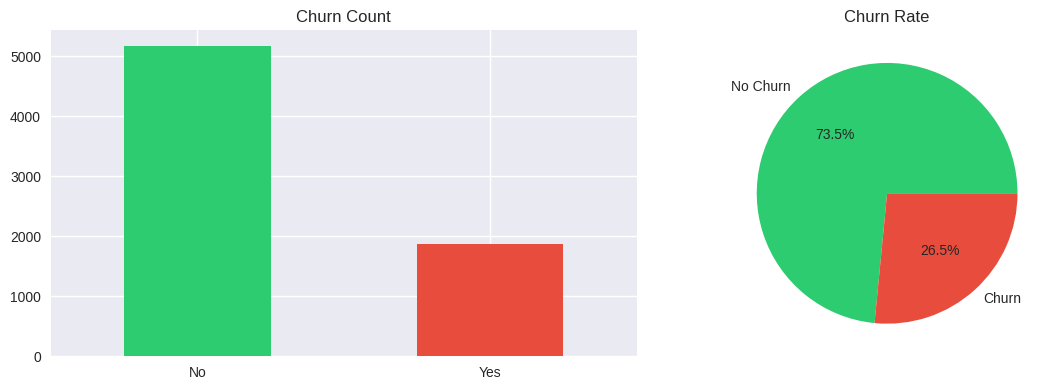

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== CHURN DISTRIBUTION ===")
print(pd.DataFrame({'count': churn_counts, 'pct': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ECC71', '#E74C3C'], rot=0)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'],
            colors=['#2ECC71', '#E74C3C'], autopct='%1.1f%%')
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig('../data/processed/churn_distribution.png', dpi=150)
plt.show()

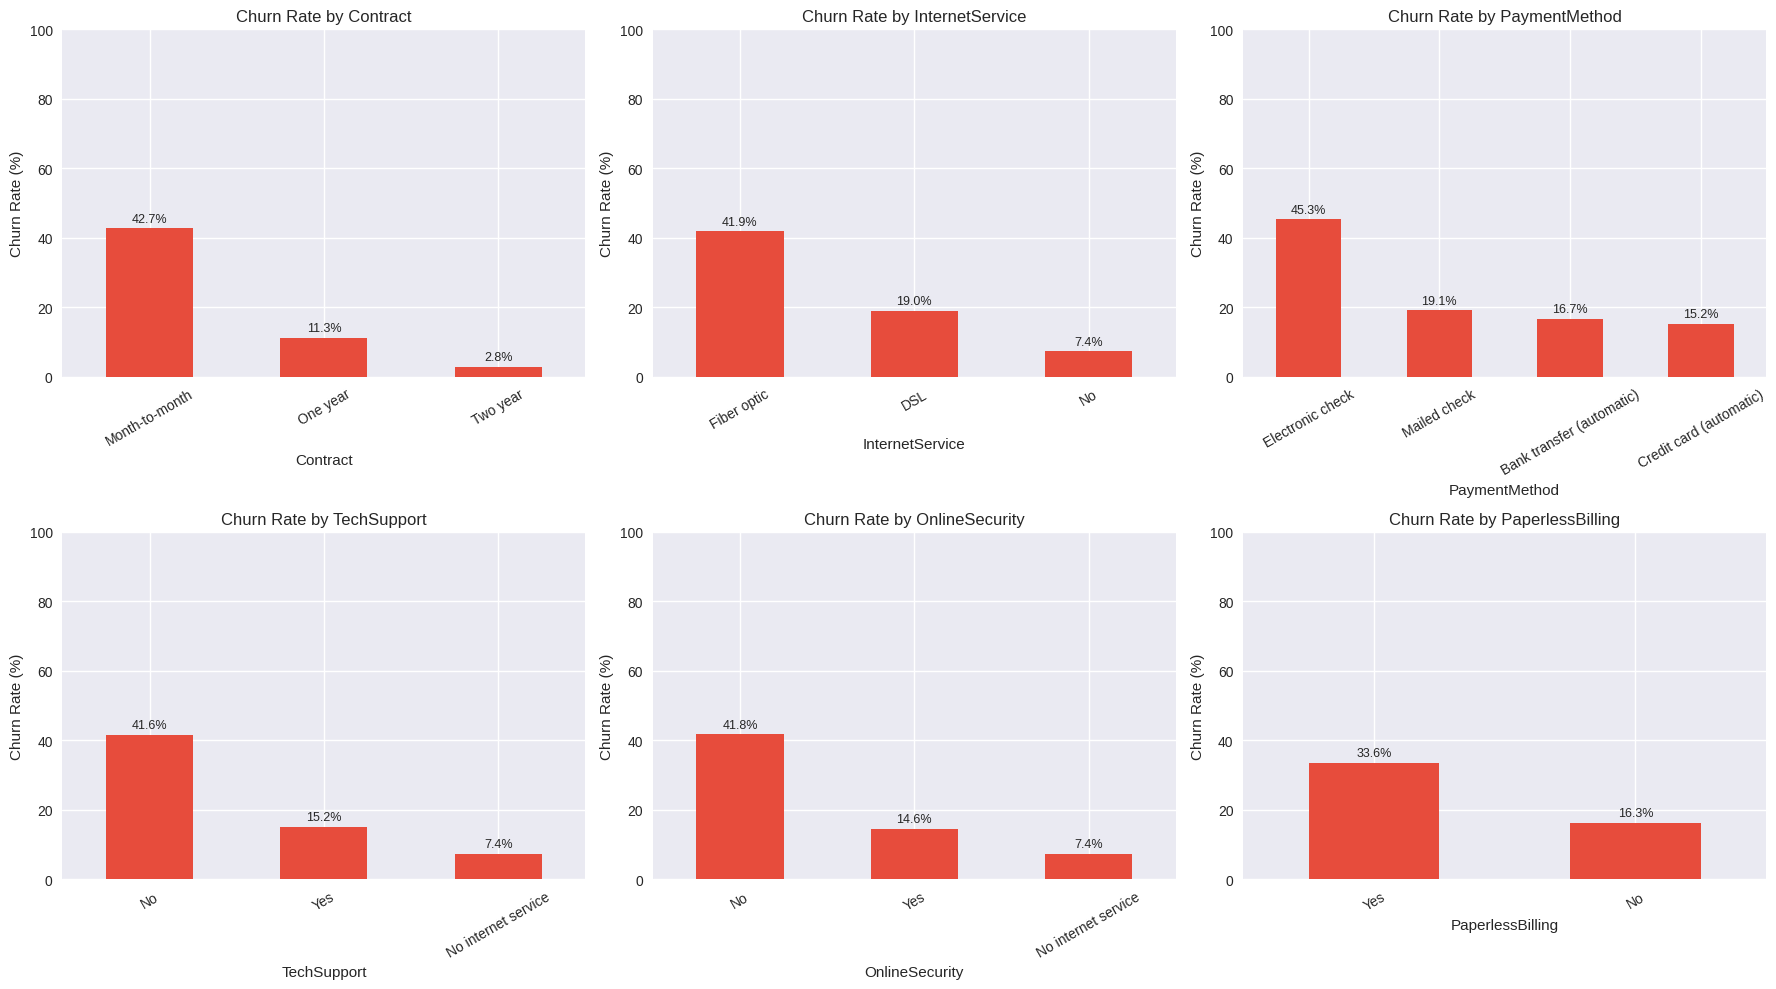

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

segments = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

for ax, col in zip(axes.flatten(), segments):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    bars = churn_rate.plot(kind='bar', ax=ax, color='#E74C3C', rot=30)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 100)
    
    for bar, val in zip(ax.patches, churn_rate):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/churn_by_segment.png', dpi=150)
plt.show()

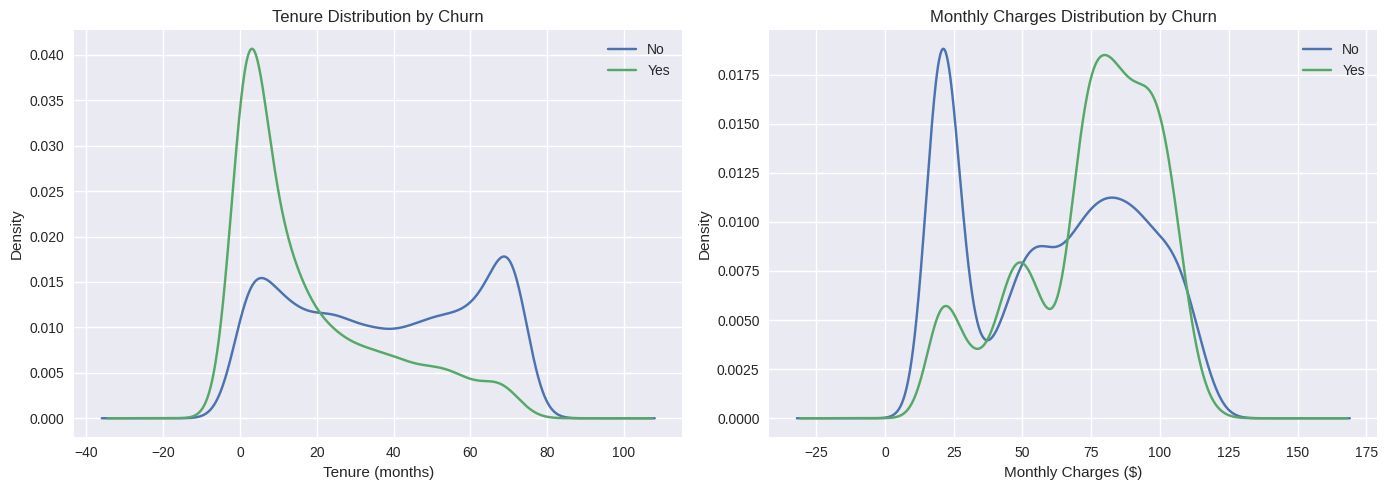

=== KEY INSIGHTS ===

Churn = Yes:
  Avg tenure: 18.0 months
  Avg MonthlyCharges: $74.44
  Avg TotalCharges: $1531.80

Churn = No:
  Avg tenure: 37.6 months
  Avg MonthlyCharges: $61.27
  Avg TotalCharges: $2549.91


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[0], legend=True)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')

# Monthly Charges distribution  
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Monthly Charges Distribution by Churn')
axes[1].set_xlabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('../data/processed/tenure_charges_distribution.png', dpi=150)
plt.show()

# Key insights
print("=== KEY INSIGHTS ===")
for churn_val in ['Yes', 'No']:
    subset = df[df['Churn'] == churn_val]
    print(f"\nChurn = {churn_val}:")
    print(f"  Avg tenure: {subset['tenure'].mean():.1f} months")
    print(f"  Avg MonthlyCharges: ${subset['MonthlyCharges'].mean():.2f}")
    print(f"  Avg TotalCharges: ${subset['TotalCharges'].mean():.2f}")

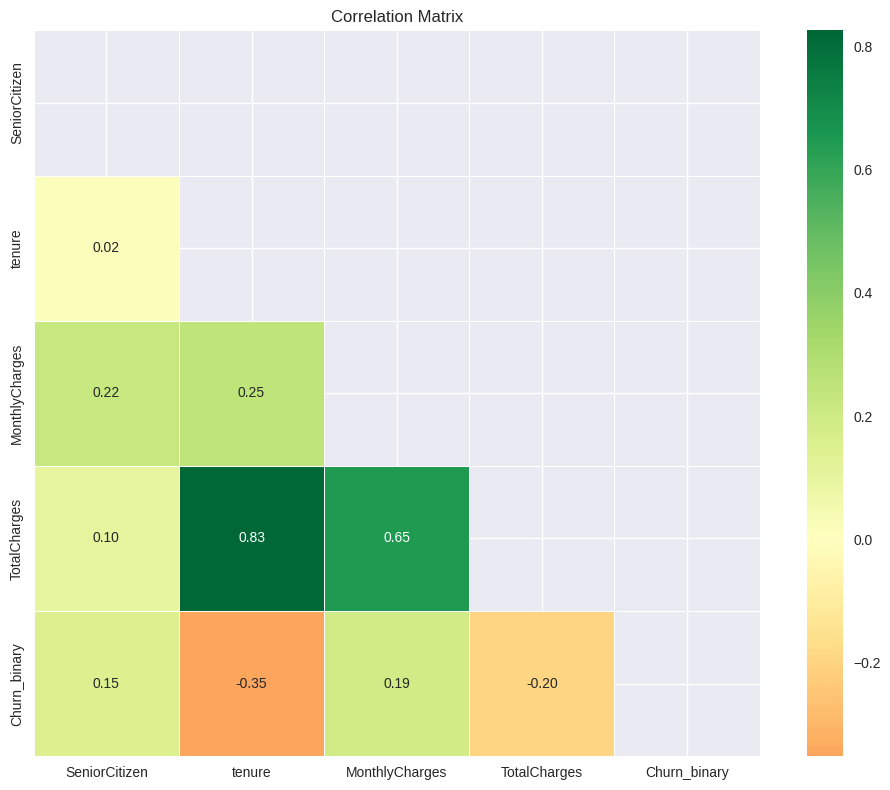

=== TOP CORRELATIONS WITH CHURN ===
Churn_binary      1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_binary, dtype: float64


In [8]:
# Encode binary columns
df_encoded = df.copy()
df_encoded['Churn_binary'] = (df_encoded['Churn'] == 'Yes').astype(int)

# Chỉ lấy numeric columns
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

# Top correlations với Churn
print("=== TOP CORRELATIONS WITH CHURN ===")
print(corr_matrix['Churn_binary'].sort_values(ascending=False))

In [9]:
# Convert Churn sang binary
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Save
df.to_csv('../data/processed/telco_clean.csv', index=False)

print(f"Clean data saved ✅")
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn_binary'].mean()*100:.2f}%")

Clean data saved ✅
Shape: (7043, 22)
Churn rate: 26.54%
